# Tutorial Part 4 — Keras Tuner for Hyperparameter Sweeps

This tutorial uses **Keras Tuner** to automatically search the full
hyperparameter space of `FairKernelRidge` (σ, λ, μ, σ_q, epochs, lr)
and visualize the fairness-accuracy Pareto frontier.

**Outline**

1. The `FairKernelRidgeHyperModel`
2. Running the search
3. Analyzing results
4. Canonical plot — fairness vs accuracy (from all trials)

In [1]:
from __future__ import annotations

import os

os.environ["KERAS_BACKEND"] = "jax"

import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np

from fairkl.tuning import FairKernelRidgeHyperModel
from _style import style_ax

## Same Synthetic Data

In [2]:
rng = np.random.default_rng(0)
n = 200
x = rng.standard_normal((n, 1)).astype("float32")
q = rng.standard_normal((n, 1)).astype("float32")
X = np.hstack([x, q]).astype("float32")
y = (np.sin(x.ravel()) + 3.0 * q.ravel() + 0.3 * rng.standard_normal(n)).astype(
    "float32"
)

# Train / validation split
n_train = 150
X_train, X_val = X[:n_train], X[n_train:]
y_train, y_val = y[:n_train], y[n_train:]
q_train, q_val = q[:n_train], q[n_train:]
print(f"Train: {n_train},  Val: {n - n_train}")

Train: 150,  Val: 50


---
## 1  The `FairKernelRidgeHyperModel`

`fairkl.tuning.FairKernelRidgeHyperModel` is a
`keras_tuner.HyperModel` subclass that defines the search space.

In [3]:
hyper_model = FairKernelRidgeHyperModel(
    X_train=X_train,
    y_train=y_train,
    q_train=q_train,
    X_val=X_val,
    y_val=y_val,
    q_val=q_val,
)

The search space includes:

| Parameter | Range | Sampling |
|-----------|-------|----------|
| σ (RBF bandwidth) | [0.1, 5.0] | log |
| λ (ridge) | [1e-4, 1.0] | log |
| μ (fairness) | [0, 20] | linear (step=1) |
| σ_q (sensitive bandwidth) | [0.1, 5.0] | log |
| epochs | [50, 300] | step=50 |
| lr | [1e-3, 0.05] | log |

---
## 2  Running the Search

We use `RandomSearch` with 30 trials.  The primary objective is
`val_mse`, but the tuner also records `val_cka` for the Pareto plot.

In [4]:
tuner = kt.RandomSearch(
    hyper_model,
    objective=kt.Objective("val_mse", direction="min"),
    max_trials=30,
    overwrite=True,
    directory="/tmp/fairkl_tuning",
    project_name="fair_krr_tutorial",
)
tuner.search_space_summary()

Search space summary
Default search space size: 4
sigma (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 5.0, 'step': None, 'sampling': 'log'}
lam (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 1.0, 'step': None, 'sampling': 'log'}
mu (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 20.0, 'step': 1.0, 'sampling': 'linear'}
sigma_q (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 5.0, 'step': None, 'sampling': 'log'}


In [5]:
tuner.search()

Trial 30 Complete [00h 00m 08s]
val_mse: 2.4717583656311035

Best val_mse So Far: 0.13535723090171814
Total elapsed time: 00h 04m 41s


---
## 3  Analyzing Results

### 3.1  Best hyperparameters

In [6]:
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")

Best hyperparameters:
  sigma: 0.4971597820765931
  lam: 0.09089278200917085
  mu: 0.0
  sigma_q: 0.23779214907445825
  epochs: 200
  lr: 0.039237027971539294


### 3.2  All trials — extract MSE, CKA, and μ

In [7]:
all_trials = tuner.oracle.get_best_trials(num_trials=30)
trial_mses, trial_ckas, trial_mus = [], [], []

for trial in all_trials:
    hp = trial.hyperparameters.values
    mse_obs = trial.metrics.metrics["val_mse"].get_history()
    cka_obs = trial.metrics.metrics["val_cka"].get_history()
    trial_mses.append(mse_obs[-1].value[0])
    trial_ckas.append(cka_obs[-1].value[0])
    trial_mus.append(hp["mu"])

trial_mses = np.array(trial_mses)
trial_ckas = np.array(trial_ckas)
trial_mus = np.array(trial_mus)

print(f"Collected {len(trial_mses)} trials")
print(f"MSE  range: [{trial_mses.min():.3f}, {trial_mses.max():.3f}]")
print(f"CKA  range: [{trial_ckas.min():.3f}, {trial_ckas.max():.3f}]")

Collected 30 trials
MSE  range: [0.135, 7.278]
CKA  range: [0.011, 0.743]


### 3.3  Pareto-optimal trials

A trial is **Pareto-optimal** if no other trial has both lower MSE
*and* lower CKA.

In [8]:
is_pareto = np.ones(len(trial_mses), dtype=bool)
for i in range(len(trial_mses)):
    for j in range(len(trial_mses)):
        if (
            i != j
            and trial_mses[j] <= trial_mses[i]
            and trial_ckas[j] <= trial_ckas[i]
            and (trial_mses[j] < trial_mses[i] or trial_ckas[j] < trial_ckas[i])
        ):
            is_pareto[i] = False
            break

n_pareto = is_pareto.sum()
print(f"{n_pareto} Pareto-optimal trials out of {len(trial_mses)}")

# Sort Pareto front by CKA for line plot
pareto_idx = np.where(is_pareto)[0]
sort_order = np.argsort(trial_ckas[pareto_idx])
pareto_ckas = trial_ckas[pareto_idx][sort_order]
pareto_mses = trial_mses[pareto_idx][sort_order]
pareto_mus = trial_mus[pareto_idx][sort_order]

13 Pareto-optimal trials out of 30


---
## 4  Canonical Plot — Fairness vs Accuracy

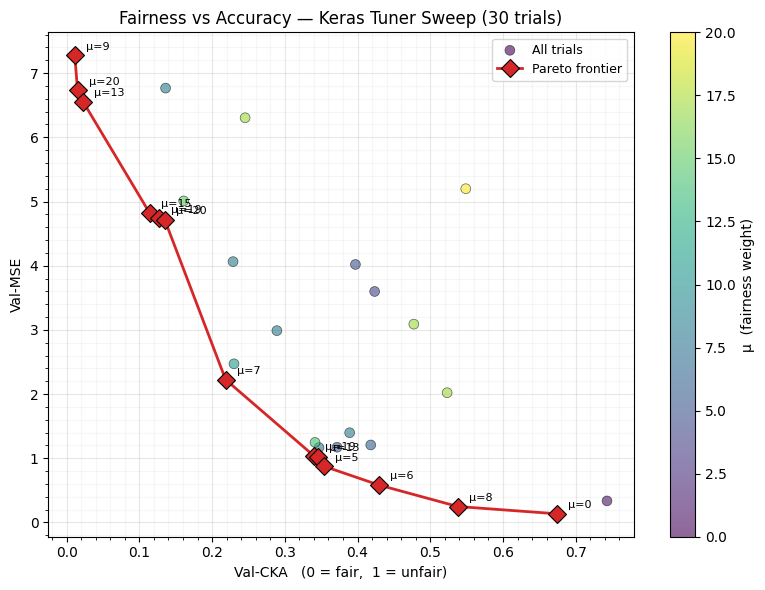

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

# All trials colored by mu
sc = ax.scatter(
    trial_ckas,
    trial_mses,
    c=trial_mus,
    cmap="viridis",
    s=50,
    edgecolors="k",
    linewidths=0.5,
    alpha=0.6,
    zorder=3,
    label="All trials",
)
plt.colorbar(sc, ax=ax, label="μ  (fairness weight)")

# Pareto frontier
ax.plot(
    pareto_ckas,
    pareto_mses,
    "D-",
    color="C3",
    lw=2,
    markersize=9,
    markeredgecolor="k",
    markeredgewidth=0.8,
    zorder=5,
    label="Pareto frontier",
)

# Annotate Pareto points with mu
for i in range(len(pareto_ckas)):
    ax.annotate(
        f"μ={pareto_mus[i]:.0f}",
        (pareto_ckas[i], pareto_mses[i]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=8,
    )

ax.set_xlabel("Val-CKA   (0 = fair,  1 = unfair)")
ax.set_ylabel("Val-MSE")
ax.set_title("Fairness vs Accuracy — Keras Tuner Sweep (30 trials)", fontsize=12)
ax.legend(fontsize=9)
style_ax(ax)
plt.tight_layout()
plt.show()

**Key takeaway**: Keras Tuner explores the full hyperparameter space
simultaneously -- not just mu, but also sigma, lam, sigma_q, epochs, and lr.
The Pareto frontier extracted from all trials gives the richest
picture of the fairness-accuracy trade-off.

---

**Series summary**:

| Part | Focus | Pareto source |
|------|-------|---------------|
| [Part 1](tutorial_fair_krr_part1.py) | Math & primitives | Training metrics |
| [Part 2](tutorial_fair_krr_part2.py) | Scikit-learn & CV | Cross-validated metrics |
| [Part 3](tutorial_fair_krr_part3.py) | fairkl API & Keras | Training metrics |
| **Part 4** | **Keras Tuner** | **Multi-HP Pareto from 30 trials** |